## Document Analysis: Computational Methods - Summer Term 2025
### Lectures: Jun.-Prof. Dr. Andreas Spitz
### Tutorials: Julian Schelb

# Exercise 06

### You will learn about:

- Word Embeddings (word2vec)

---

## Task 1 - Word2Vec:

### Part 1:
Explain the difference between the continuous bag of words (CBOW) and Skip-Gram versions of word2vec.

CBOW is a type of training in which computer learn to predict a missing word. \
Skip-gram is training in which computer tries to predict the context.


---

### Part 2: 
Given the sentence "You shall know a word by the company it keeps" and a sliding window size of l=5 (two to the left, two to the right), generate a list of all positive training data (input and output) that

a) CBOW creates for the word "company".

b) Skip-Gram creates for the word "word".

You shall know a word by the company it keeps

a) 

by          company

the         company

it          company

keeps       company


b)

input       output

word        know

word        a

word        by

word        the


---

## Task 2 - Similarity:

### Part 1:
Given The following 5-dimensional vector embeddings for three words, manually compute cosine similarities to determine whether a boat is more similar to an apple or to an orange.

apple = [1,5,3,3,2]

orange = [2,5,2,4,2]

boat = [6,1,8,4,2]

apple/boat = (1 * 6 + 5 * 1 +  3 * 8 + 3 * 4 + 2 * 2) / (1 + 25 + 9 + 9 + 4)^0.5 * (36 + 1 + 64 + 16 + 4) = (51)/ (48 * 121)^0.5 

orange / boat = (2 * 6 + 5 * 1 + 2 * 8 + 4 * 4 + 4)/ (4 + 25 + 4 + 16 + 5)^0.5 * (121) ^ 0.5 = (53) / (54 * 121)^ 0.5 

---

#### Part 2:

What are the implications of being able to compute arbitrary pairwise word similarities as in the example above?

1) Better semantical search (synonyms: car, automobile)
2) Better IR search: doctor, also psysician
3) Clustering in semantical groups
4) Pos-tag, NER, machine translation, also use it 

---

#### Part 3:

Using a pre-trained word2vec model from gensim package, investigate the claim that embeddings encode semantic relations via compositional semantics, such als "king - man + woman = queen". For each of the following examples, use the model to generate the three input vectors, compute the target vector, and retrieve the 10 most similar words by cosine similarity. Discuss your findings.

Examples:

- king - man + woman
- France - Paris + Tokyo
- sister - brother + grandson
- bigger - big + cold
- scientist - Einstein + Picasso

In [6]:
# load pre-trained word2vec
# you first need to download the bin file of the model, do not submit this file!!! since it will be larger than 1GB

from gensim.models import KeyedVectors
model = KeyedVectors.load_word2vec_format(r'GoogleNews-vectors-negative300.bin', binary=True)


# TODO - ADD YOUR CODE HERE

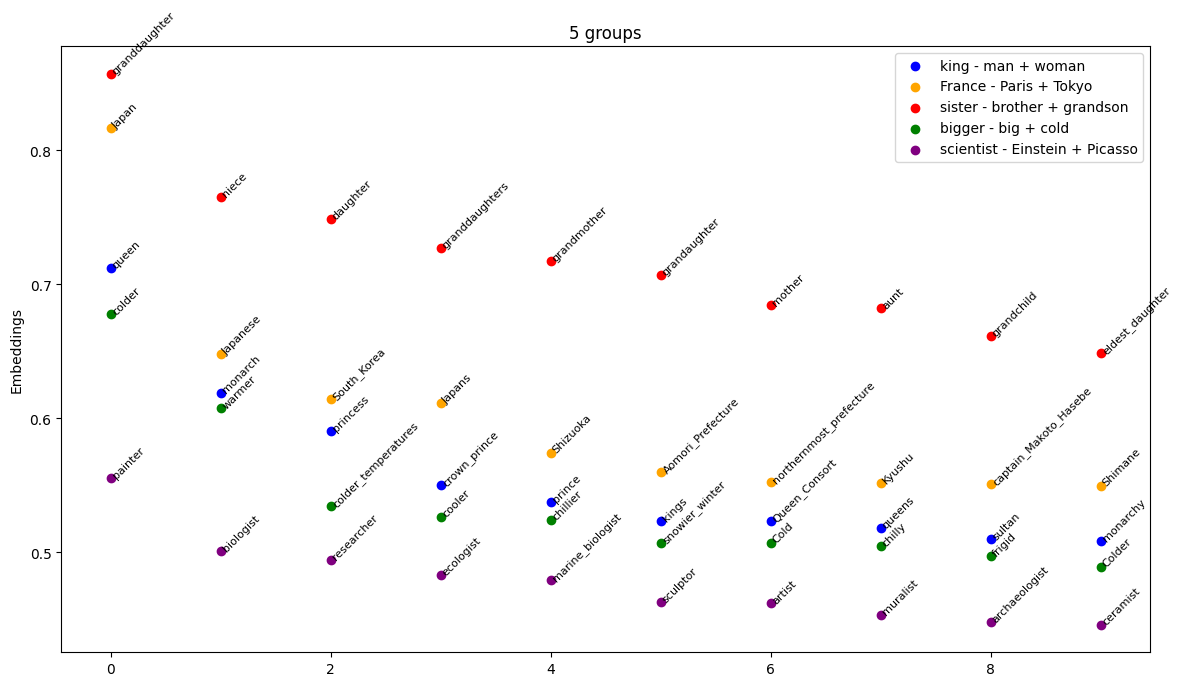

In [ ]:
import matplotlib.pyplot as plt

ex1 = model.most_similar(positive= ['woman', 'king'], negative=['man'])
ex2 = model.most_similar(positive= ['France', 'Tokyo'], negative=['Paris'])
ex3 = model.most_similar(positive= ['sister', 'grandson'], negative=['brother'])
ex4 = model.most_similar(positive= ['bigger', 'cold'], negative=['big'])
ex5 = model.most_similar(positive= ['scientist', 'Picasso'], negative=['Einstein'])



# JUST FOR FUN :)
datasets = [ex1, ex2, ex3, ex4, ex5]

labels = ["king - man + woman", "France - Paris + Tokyo", "sister - brother + grandson", "bigger - big + cold", "scientist - Einstein + Picasso"]
colors = ["blue", "orange", "red", "green", "purple"]



plt.figure(figsize=(12, 7))
offset = 0

for data, label, color in zip(datasets, labels, colors):
    words, values = zip(*data)
    x = [i + offset for i in range(len(values))]
    plt.scatter(x, values, label=label, color=color)
    for i, txt in enumerate(words):
        plt.annotate(txt, (x[i], values[i]), fontsize=8, rotation=45)
    #offset += len(values) + 2 
plt.title("5 groups")
plt.ylabel("Embeddings")
plt.legend()
plt.tight_layout()
plt.show()

<font color='ff000000'>\# TEXT SUBMISSION ANSWER HERE (Double click to edit) </font>

## Task 3 - Embedding Visualization:

### Part 1:
Your task is to calculate the pair-wise similarities between the first 500 critics of the 'rottentomatoes' dataset from the earlier assignment (this time work on single critics, i.e., sentences).
Calculate the pairwise similarity between their average word2vec embedding vectors and visualize the results.

In [16]:
import sklearn
import plotly.express as px
import json

with open('rottentomatoes.json', 'r') as infile:
    data = json.load(infile)

dataset_s = []
for comments in data:
    for i in comments['_critics']:
        dataset_s.append(comments['_critics'][i])


texts = dataset_s[:500]
dataset_v = [model.get_mean_vector(t) for t in texts]


distances = sklearn.metrics.pairwise_distances(dataset_v, metric='cosine')
similarities = 1 - distances


heatmap = px.imshow(
    similarities,
    labels=dict(color="Cosine similarity"),
    x=list(range(len(texts))),  
    y=list(range(len(texts))),
    color_continuous_scale="Viridis"
)

heatmap.update_xaxes(showticklabels=False)
heatmap.update_yaxes(showticklabels=False)
heatmap.show()


#### Submitting your results:

To submit your results, please:

- save this file, i.e., `ex??_assignment.ipynb`.
- if you reference any external files (e.g., images), please create a zip or rar archieve and put the notebook files and all referenced files in there.
- login to ILIAS and submit the `*.ipynb` or archive for the corresponding assignment.

**Remarks:**
    
- Do not copy any code from the Internet. In case you want to use publicly available code, please, add the reference to the respective code snippet.
- Check your code compiles and executes, even after you have restarted the Kernel.
- Submit your written solutions and the coding exercises within the provided spaces and not otherwise.
- Write the names of your partner and your name in the top section.